In [6]:
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


In [7]:
df = pd.read_csv("../swift_burst_data.txt", delimiter= "\t", encoding = "latin1")

In [8]:
df.head(2)

,GRB,Time [UT],Trigger Number,BAT RA (J2000),BAT Dec (J2000),BAT 90% Error Radius [arcmin],BAT T90 [sec],BAT Fluence (15-150 keV) [10^-7 erg/cm^2],BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2],BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec],...,UVOT 90% Error Radius [arcsec],UVOT Time to First Observation [sec],UVOT Magnitude,UVOT Other Filter Magnitudes,Other Observatory Detections,Redshift,Host Galaxy,Comments,References,Burst Advocate
0,250331C,04:37:40,1299967,80.993,33.029,3,NaN,NaN,NaN,NaN,...,NaN,139,NaN,NaN,NaN,NaN,NaN,NaN,BAT: GCN 39959|XRT: GCN 39959; GCN 39960; GCN ...,Brad Cenko
1,250331B,04:19:43,1299965,71.381,43.805,3,NaN,NaN,NaN,NaN,...,NaN,317,NaN,White>19.6,NaN,NaN,NaN,NaN,BAT: GCN 39958|XRT: GCN 39958; GCN 39974; GCN ...,Brad Cenko


In [9]:
df.describe()

,BAT RA (J2000),BAT Dec (J2000),BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec],BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec],XRT 90% Error Radius [arcsec],XRT 11 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s],XRT Spectral Index (Gamma),XRT Column Density (NH) [10^21 cm^-2]
count,1698.000000,1698.000000,1551.000000,1547.000000,1381.000000,1353.000000,1405.000000,1405.000000
mean,180.874866,2.831430,4.139852,0.313142,1.910913,0.155228,2.062960,5.623895
std,104.353416,41.386243,12.605058,0.324452,0.985266,0.527018,1.286381,10.769524
min,0.127000,-89.029000,0.000000,0.000000,1.400000,-0.157401,0.883481,0.000000
25%,89.500500,-30.265250,0.800000,0.200000,1.400000,0.015167,1.822810,1.080055
50%,186.046500,3.576000,1.500000,0.200000,1.500000,0.045327,1.995570,2.589120
75%,270.876250,36.076250,3.400000,0.300000,2.000000,0.125770,2.171190,5.765250
max,358.751000,89.180000,331.000000,4.600000,15.000000,11.349125,47.177400,198.137000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1699 entries, 0 to 1698
Data columns (total 35 columns):
 #   Column                                                                         Non-Null Count  Dtype  
---  ------                                                                         --------------  -----  
 0   GRB                                                                            1699 non-null   object 
 1   Time [UT]                                                                      1691 non-null   object 
 2   Trigger Number                                                                 1699 non-null   object 
 3   BAT RA (J2000)                                                                 1698 non-null   float64
 4   BAT Dec (J2000)                                                                1698 non-null   float64
 5   BAT 90% Error Radius [arcmin]                                                  1690 non-null   object 
 6   BAT T90 [sec]           

# EDA and Data Cleaning

### Inspecting data

<Axes: >

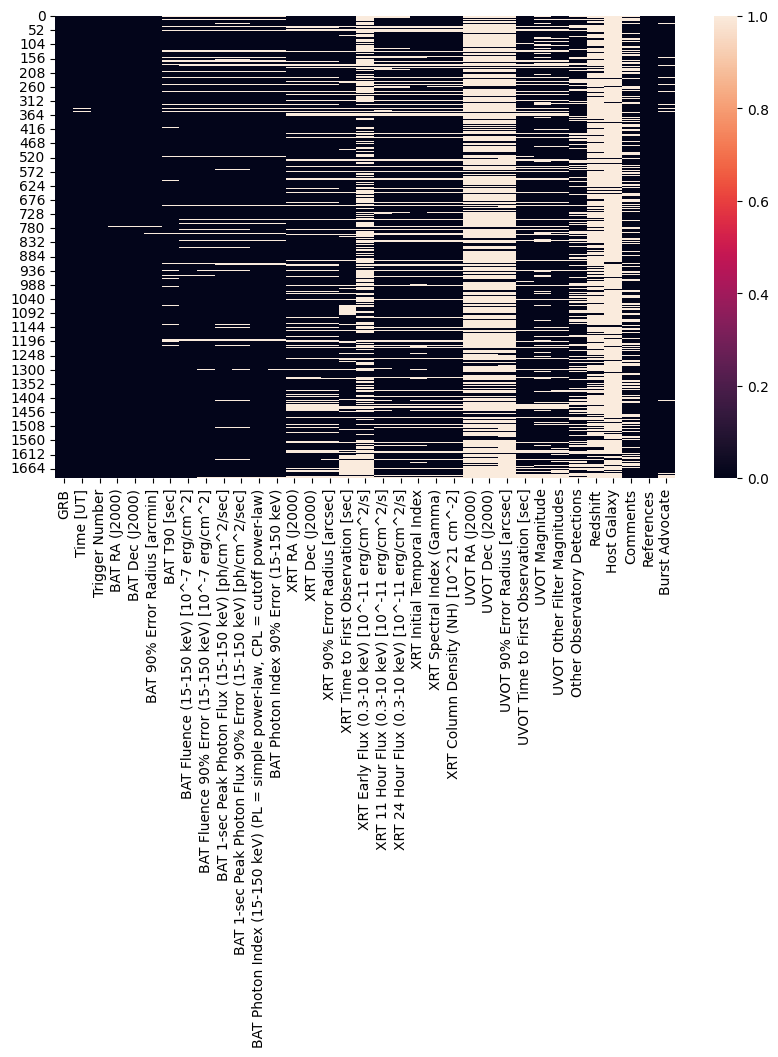

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull())

Getting all the columns which are dtype numerical (float)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1699 entries, 0 to 1698
Data columns (total 35 columns):
 #   Column                                                                         Non-Null Count  Dtype  
---  ------                                                                         --------------  -----  
 0   GRB                                                                            1699 non-null   object 
 1   Time [UT]                                                                      1691 non-null   object 
 2   Trigger Number                                                                 1699 non-null   object 
 3   BAT RA (J2000)                                                                 1698 non-null   float64
 4   BAT Dec (J2000)                                                                1698 non-null   float64
 5   BAT 90% Error Radius [arcmin]                                                  1690 non-null   object 
 6   BAT T90 [sec]           

In [13]:
df.describe()

,BAT RA (J2000),BAT Dec (J2000),BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec],BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec],XRT 90% Error Radius [arcsec],XRT 11 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s],XRT Spectral Index (Gamma),XRT Column Density (NH) [10^21 cm^-2]
count,1698.000000,1698.000000,1551.000000,1547.000000,1381.000000,1353.000000,1405.000000,1405.000000
mean,180.874866,2.831430,4.139852,0.313142,1.910913,0.155228,2.062960,5.623895
std,104.353416,41.386243,12.605058,0.324452,0.985266,0.527018,1.286381,10.769524
min,0.127000,-89.029000,0.000000,0.000000,1.400000,-0.157401,0.883481,0.000000
25%,89.500500,-30.265250,0.800000,0.200000,1.400000,0.015167,1.822810,1.080055
50%,186.046500,3.576000,1.500000,0.200000,1.500000,0.045327,1.995570,2.589120
75%,270.876250,36.076250,3.400000,0.300000,2.000000,0.125770,2.171190,5.765250
max,358.751000,89.180000,331.000000,4.600000,15.000000,11.349125,47.177400,198.137000


In [14]:
df.shape

(1699, 35)

### Dealing with missing values

removing features with majority of null values

<Axes: >

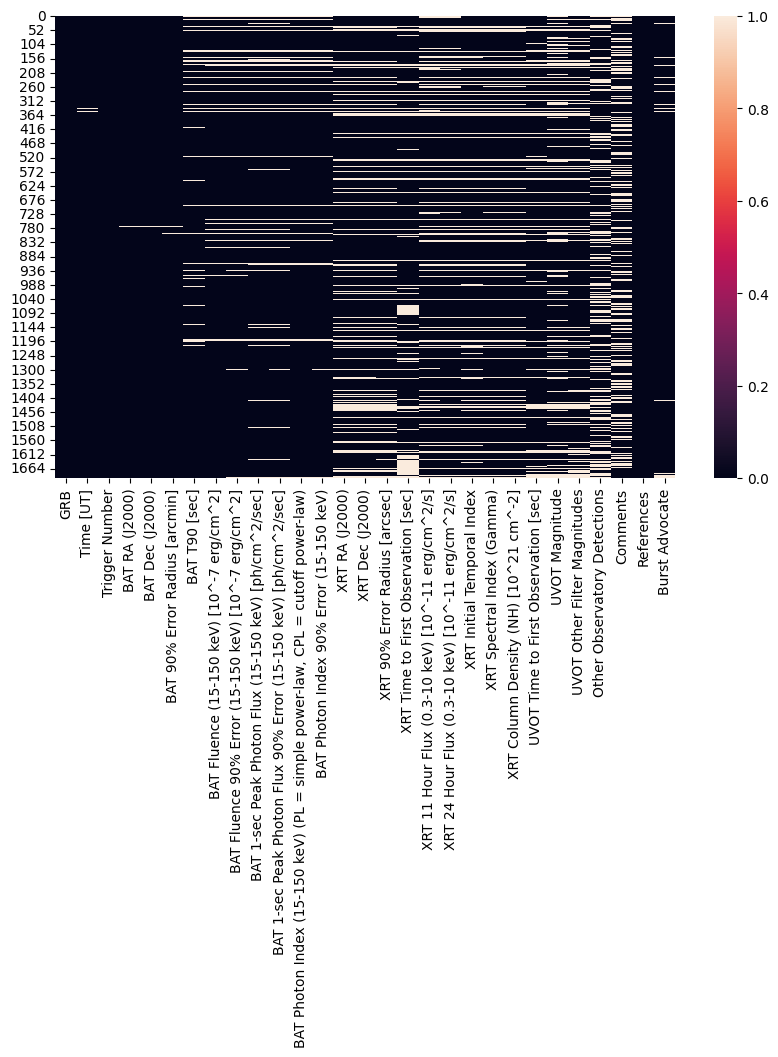

In [15]:
df2 = df.drop(["XRT Early Flux (0.3-10 keV) [10^-11 erg/cm^2/s]", "UVOT RA (J2000)","UVOT Dec (J2000)","UVOT 90% Error Radius [arcsec]","Redshift","Host Galaxy"], axis= 1)
plt.figure(figsize=(10,6))
sns.heatmap(df2.isnull())

Checking values for features that seem to have majority of values as null values:

In [16]:
df["Comments"].isnull().value_counts()        

Comments
False    1127
True      572
Name: count, dtype: int64

In [17]:
df["Other Observatory Detections"].isnull().value_counts()

Other Observatory Detections
False    1202
True      497
Name: count, dtype: int64

In [18]:
df[df["Time [UT]"].isnull()]

,GRB,Time [UT],Trigger Number,BAT RA (J2000),BAT Dec (J2000),BAT 90% Error Radius [arcmin],BAT T90 [sec],BAT Fluence (15-150 keV) [10^-7 erg/cm^2],BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2],BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec],...,UVOT 90% Error Radius [arcsec],UVOT Time to First Observation [sec],UVOT Magnitude,UVOT Other Filter Magnitudes,Other Observatory Detections,Redshift,Host Galaxy,Comments,References,Burst Advocate
77,240101A,NaN,1205708,10.2890,8.5400,3.8,15.8,3.3,0.7,0.9,...,NaN,168,V>18.7,B>18.9|U>18.3|UVW1>19.5|UVW2>18.7|White>20.8,NaN,NaN,NaN,UVOT: no detection,BAT: GCN 35448; GCN 35473|XRT: GCN 35448; GCN ...,Brad Cenko
250,210402A,NaN,1040123,198.2650,44.5100,1.2,238.7,86,4,1.6,...,NaN,NaN,V>19.6,B>20.2|U>20.2|UVW1>19.2|UVW2>18.4|White>21.4,"LBT, NOT, Fermi (GBM), MASTER-Net",NaN,NaN,BAT: Due to a ground pass at the time of the G...,BAT: GCN 29743; GCN 29761|XRT: GCN 29743; GCN ...,Kim Page
339,200405B,NaN,Ground Analysis,62.7894,-51.5326,4,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XRT: Four uncatalogued X-ray sources were dete...,BAT: GCN 27497|XRT: GCN 27500; GCN 27568,Sibasish Laha
340,200325A,NaN,Ground Analysis,31.7203,-31.8160,4,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"Fermi (GMB), AGILE, AstroSat, IPN",NaN,NaN,Detected by Fermi GBM (GCN 27434) which trigge...,BAT: GCN 27444,NaN
346,200228A,NaN,Ground Analysis,333.8928,-42.9443,3,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"Fermi (GBM), AstroSat (CZTI)",NaN,NaN,No XRT or UVOT follow-up will take place due t...,BAT: GCN 27259,NaN
351,200216A,NaN,Ground Analysis,311.4378,-11.6580,3,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Fermi (GBM),NaN,NaN,No XRT or UVOT follow-up will take place due t...,BAT: GCN 27107|XRT: GCN 27107|UVOT: GCN 27107,NaN
1018,120701A,NaN,525477,80.3380,-58.5310,1.3,13.8,14,1,1.6,...,NaN,89,V>18.8,B>20.3|U_fc=19.16|U>19.9|UVW1>20.6|UVM2>20.7|U...,MPG/ESO (2.2m),NaN,NaN,There was no initial set of GCN Notices nor a ...,"BAT: GCN 13404|XRT: GCN 13406; Evans et al., 2...",Eda Sonbas
1019,120630A,NaN,525451,352.3000,42.4950,2.7,0.6,0.61,0.14,0.7,...,NaN,150,V>19.0,B>20.0|U>20.3|UVW1>19.3|UVM2>19.0|UVW2>19.5,NOT (2.5m),NaN,NaN,There was no initial set of GCN Notices nor a ...,"BAT: GCN 13405|XRT: GCN 13405; Evans et al., 2...",NaN


In [19]:
df2 = df2[df2["Time [UT]"].notnull()]

<Axes: >

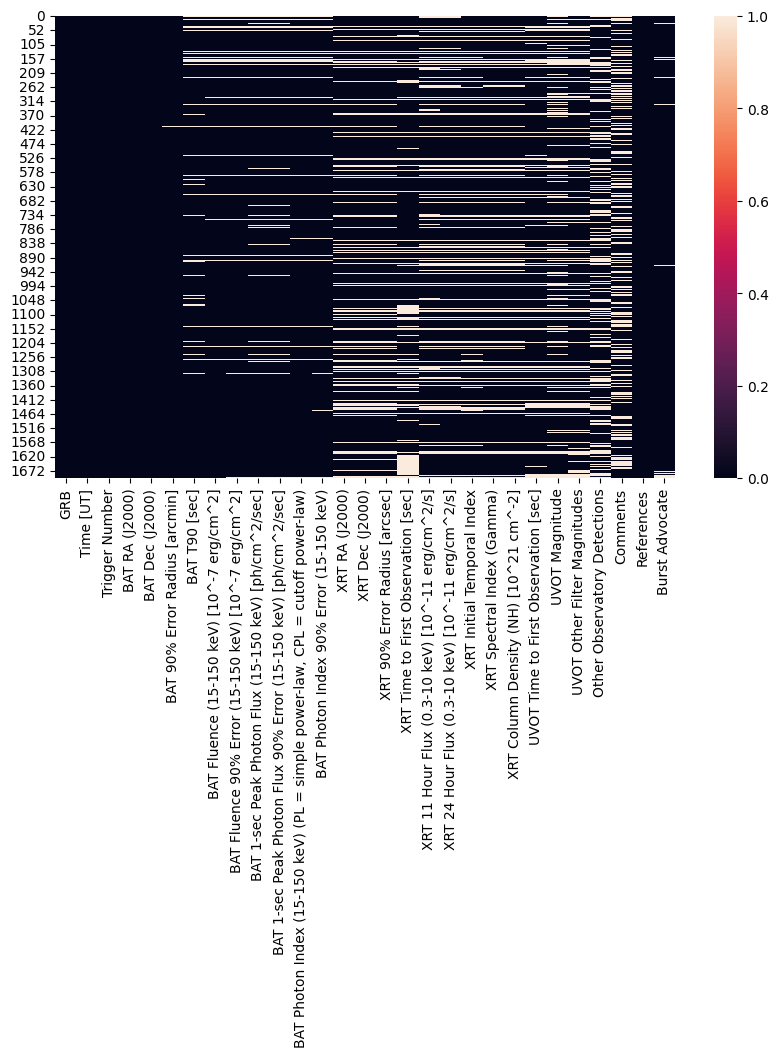

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(df2.isnull())

In [21]:
df2.shape

(1691, 29)

In [22]:
df.shape

(1699, 35)

In [23]:
df2.describe()

,BAT RA (J2000),BAT Dec (J2000),BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec],BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec],XRT 90% Error Radius [arcsec],XRT 11 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s],XRT Spectral Index (Gamma),XRT Column Density (NH) [10^21 cm^-2]
count,1690.000000,1690.000000,1547.000000,1543.000000,1378.000000,1349.000000,1401.000000,1401.000000
mean,180.913899,2.904559,4.147453,0.313435,1.910864,0.155572,2.063060,5.632545
std,104.187517,41.387131,12.620449,0.324821,0.986307,0.527755,1.288186,10.783415
min,0.127000,-89.029000,0.000000,0.000000,1.400000,-0.157401,0.883481,0.000000
25%,90.076500,-29.822000,0.800000,0.200000,1.400000,0.015206,1.822810,1.080055
50%,186.046500,3.640500,1.500000,0.200000,1.500000,0.045349,1.995440,2.589120
75%,270.795000,36.076250,3.400000,0.300000,2.000000,0.126028,2.171190,5.768700
max,358.751000,89.180000,331.000000,4.600000,15.000000,11.349125,47.177400,198.137000


In [24]:
def missing(feature):   #created a function to determine total number of missing values in each column
    return feature.isnull().value_counts()


In [25]:
for columns in df2.columns:
    print(missing(df2[columns]))

GRB
False    1691
Name: count, dtype: int64
Time [UT]
False    1691
Name: count, dtype: int64
Trigger Number
False    1691
Name: count, dtype: int64
BAT RA (J2000)
False    1690
True        1
Name: count, dtype: int64
BAT Dec (J2000)
False    1690
True        1
Name: count, dtype: int64
BAT 90% Error Radius [arcmin]
False    1682
True        9
Name: count, dtype: int64
BAT T90 [sec]
False    1570
True      121
Name: count, dtype: int64
BAT Fluence (15-150 keV) [10^-7 erg/cm^2]
False    1592
True       99
Name: count, dtype: int64
BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2]
False    1583
True      108
Name: count, dtype: int64
BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec]
False    1547
True      144
Name: count, dtype: int64
BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec]
False    1543
True      148
Name: count, dtype: int64
BAT Photon Index (15-150 keV) (PL = simple power-law, CPL = cutoff power-law)
False    1595
True       96
Name: count, dtype: int64


Checking the number of missing values in numerical columns:

In [26]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1691 entries, 0 to 1698
Data columns (total 29 columns):
 #   Column                                                                         Non-Null Count  Dtype  
---  ------                                                                         --------------  -----  
 0   GRB                                                                            1691 non-null   object 
 1   Time [UT]                                                                      1691 non-null   object 
 2   Trigger Number                                                                 1691 non-null   object 
 3   BAT RA (J2000)                                                                 1690 non-null   float64
 4   BAT Dec (J2000)                                                                1690 non-null   float64
 5   BAT 90% Error Radius [arcmin]                                                  1682 non-null   object 
 6   BAT T90 [sec]                

#### Getting the number of null values for numerical columns

In [27]:
df2.dtypes

GRB                                                                               object
Time [UT]                                                                         object
Trigger Number                                                                    object
BAT RA (J2000)                                                                   float64
BAT Dec (J2000)                                                                  float64
BAT 90% Error Radius [arcmin]                                                     object
BAT T90 [sec]                                                                     object
BAT Fluence (15-150 keV) [10^-7 erg/cm^2]                                         object
BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2]                               object
BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec]                            float64
BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec]                  float64
BAT Photon Index (15-

In [28]:
dtype_dict = df2.dtypes.to_dict()
list_of_numerical_columns = [x for (x,y) in dtype_dict.items() if y == "float64"]

In [29]:
list_of_numerical_columns

['BAT RA (J2000)',
 'BAT Dec (J2000)',
 'BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec]',
 'BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec]',
 'XRT 90% Error Radius [arcsec]',
 'XRT 11 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s]',
 'XRT Spectral Index (Gamma)',
 'XRT Column Density (NH) [10^21 cm^-2]']

In [30]:
for columns in list_of_numerical_columns:
    print(missing(df2[columns]))

BAT RA (J2000)
False    1690
True        1
Name: count, dtype: int64
BAT Dec (J2000)
False    1690
True        1
Name: count, dtype: int64
BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec]
False    1547
True      144
Name: count, dtype: int64
BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec]
False    1543
True      148
Name: count, dtype: int64
XRT 90% Error Radius [arcsec]
False    1378
True      313
Name: count, dtype: int64
XRT 11 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s]
False    1349
True      342
Name: count, dtype: int64
XRT Spectral Index (Gamma)
False    1401
True      290
Name: count, dtype: int64
XRT Column Density (NH) [10^21 cm^-2]
False    1401
True      290
Name: count, dtype: int64


Checking missing values for numerical columns other than right ascension and declination: 

In [31]:
for columns in list_of_numerical_columns[2:]:
    print(missing(df2[columns]))

BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec]
False    1547
True      144
Name: count, dtype: int64
BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec]
False    1543
True      148
Name: count, dtype: int64
XRT 90% Error Radius [arcsec]
False    1378
True      313
Name: count, dtype: int64
XRT 11 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s]
False    1349
True      342
Name: count, dtype: int64
XRT Spectral Index (Gamma)
False    1401
True      290
Name: count, dtype: int64
XRT Column Density (NH) [10^21 cm^-2]
False    1401
True      290
Name: count, dtype: int64
